### 특성(Feature)공학과 규제(Regularization: 정형화, 규제, 일반화)

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Data/fish.csv")
df.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [3]:
# Numpy
fish_full = df.values
fish_full[:5]

array([[ 8.4 ,  2.11,  1.41],
       [13.7 ,  3.53,  2.  ],
       [15.  ,  3.82,  2.43],
       [16.2 ,  4.59,  2.63],
       [17.4 ,  4.59,  2.94]])

In [4]:
df = pd.read_csv("../Data/fish_weight.csv")
df.head()

,weight
0,5.9
1,32.0
2,40.0
3,51.5
4,70.0


In [5]:
fish_weight = df.to_numpy()
fish_weight[:6]

array([[  5.9],
       [ 32. ],
       [ 40. ],
       [ 51.5],
       [ 70. ],
       [100. ]])

#### Train과 Test 분리

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fish_full,
    fish_weight,
    random_state=42
  )

---
### 선형회귀 분석하기

In [8]:
### 선형회귀 분석으로 예측하기
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_input, train_target)
print("train :", lr.score(train_input, train_target))
print("target :", lr.score(test_input, test_target))

train : 0.9559326821885706
target : 0.8796419177546367


### 다중회귀 분석하기

In [9]:
from sklearn.preprocessing import PolynomialFeatures

### 다항 특성 만들기 연습

In [10]:
poly = PolynomialFeatures()
poly.fit([[2,3]])
print(poly.transform([[2,3]]))

[[1. 2. 3. 4. 6. 9.]]


1 : 절편   
2 : x   
3 : y   
4 : x^2  
6 : x * y   
9 : y^2     

In [11]:
# 절편이 필요 없는 경우
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2,3]])
print(poly.transform([[2,3]]))

[[2. 3. 4. 6. 9.]]


In [12]:
train_input.shape

(42, 3)

In [13]:
# 다항 특성 만들기
poly = PolynomialFeatures(include_bias=False) # degree = 2
poly.fit(train_input)
train_poly = poly.transform(train_input)


# poly = PolynomialFeatures(include_bias=False) # degree = 2

# train_poly = poly.fit_transform(train_input)

In [14]:
train_poly.shape

(42, 9)

In [15]:
train_poly[0:5]

array([[  19.6   ,    5.14  ,    3.04  ,  384.16  ,  100.744 ,   59.584 ,
          26.4196,   15.6256,    9.2416],
       [  22.    ,    5.88  ,    3.52  ,  484.    ,  129.36  ,   77.44  ,
          34.5744,   20.6976,   12.3904],
       [  18.7   ,    5.2   ,    3.12  ,  349.69  ,   97.24  ,   58.344 ,
          27.04  ,   16.224 ,    9.7344],
       [  17.4   ,    4.59  ,    2.94  ,  302.76  ,   79.866 ,   51.156 ,
          21.0681,   13.4946,    8.6436],
       [  36.    ,   10.61  ,    6.74  , 1296.    ,  381.96  ,  242.64  ,
         112.5721,   71.5114,   45.4276]])

In [16]:
test_poly = poly.transform(test_input)

In [17]:
# 컬럼 정보 확인
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

---
### 다중 회귀 모델 훈련하기

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print("train :", lr.score(train_poly, train_target))
print("test :", lr.score(test_poly, test_target))

train : 0.9903183436982125
test : 0.9714559911594159


---
### 더 많은 특성 만들기
: degree = 5

In [19]:
# 다항 특성 만들기
poly = PolynomialFeatures(degree=5, include_bias=False) # degree = 5
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [20]:
train_poly.shape

(42, 55)

In [21]:
train_poly[0:5]

array([[1.96000000e+01, 5.14000000e+00, 3.04000000e+00, 3.84160000e+02,
        1.00744000e+02, 5.95840000e+01, 2.64196000e+01, 1.56256000e+01,
        9.24160000e+00, 7.52953600e+03, 1.97458240e+03, 1.16784640e+03,
        5.17824160e+02, 3.06261760e+02, 1.81135360e+02, 1.35796744e+02,
        8.03155840e+01, 4.75018240e+01, 2.80944640e+01, 1.47578906e+05,
        3.87018150e+04, 2.28897894e+04, 1.01493535e+04, 6.00273050e+03,
        3.55025306e+03, 2.66161618e+03, 1.57418545e+03, 9.31035750e+02,
        5.50651494e+02, 6.97995264e+02, 4.12822102e+02, 2.44159375e+02,
        1.44405545e+02, 8.54071706e+01, 2.89254655e+06, 7.58555575e+05,
        4.48639873e+05, 1.98927329e+05, 1.17653518e+05, 6.95849599e+04,
        5.21676772e+04, 3.08540347e+04, 1.82483007e+04, 1.07927693e+04,
        1.36807072e+04, 8.09131319e+03, 4.78552376e+03, 2.83034868e+03,
        1.67398054e+03, 3.58769566e+03, 2.12190560e+03, 1.25497919e+03,
        7.42244501e+02, 4.38992857e+02, 2.59637799e+02],
       

In [22]:
# 컬럼 정보 확인
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2', 'x0^3', 'x0^2 x1', 'x0^2 x2', 'x0 x1^2', 'x0 x1 x2',
       'x0 x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3', 'x0^4', 'x0^3 x1',
       'x0^3 x2', 'x0^2 x1^2', 'x0^2 x1 x2', 'x0^2 x2^2', 'x0 x1^3',
       'x0 x1^2 x2', 'x0 x1 x2^2', 'x0 x2^3', 'x1^4', 'x1^3 x2',
       'x1^2 x2^2', 'x1 x2^3', 'x2^4', 'x0^5', 'x0^4 x1', 'x0^4 x2',
       'x0^3 x1^2', 'x0^3 x1 x2', 'x0^3 x2^2', 'x0^2 x1^3',
       'x0^2 x1^2 x2', 'x0^2 x1 x2^2', 'x0^2 x2^3', 'x0 x1^4',
       'x0 x1^3 x2', 'x0 x1^2 x2^2', 'x0 x1 x2^3', 'x0 x2^4', 'x1^5',
       'x1^4 x2', 'x1^3 x2^2', 'x1^2 x2^3', 'x1 x2^4', 'x2^5'],
      dtype=object)

In [23]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print("train :", lr.score(train_poly, train_target))
print("test :", lr.score(test_poly, test_target))

train : 0.999999999999769
test : -144.40490595353674


In [24]:
train_poly[0:5]

array([[1.96000000e+01, 5.14000000e+00, 3.04000000e+00, 3.84160000e+02,
        1.00744000e+02, 5.95840000e+01, 2.64196000e+01, 1.56256000e+01,
        9.24160000e+00, 7.52953600e+03, 1.97458240e+03, 1.16784640e+03,
        5.17824160e+02, 3.06261760e+02, 1.81135360e+02, 1.35796744e+02,
        8.03155840e+01, 4.75018240e+01, 2.80944640e+01, 1.47578906e+05,
        3.87018150e+04, 2.28897894e+04, 1.01493535e+04, 6.00273050e+03,
        3.55025306e+03, 2.66161618e+03, 1.57418545e+03, 9.31035750e+02,
        5.50651494e+02, 6.97995264e+02, 4.12822102e+02, 2.44159375e+02,
        1.44405545e+02, 8.54071706e+01, 2.89254655e+06, 7.58555575e+05,
        4.48639873e+05, 1.98927329e+05, 1.17653518e+05, 6.95849599e+04,
        5.21676772e+04, 3.08540347e+04, 1.82483007e+04, 1.07927693e+04,
        1.36807072e+04, 8.09131319e+03, 4.78552376e+03, 2.83034868e+03,
        1.67398054e+03, 3.58769566e+03, 2.12190560e+03, 1.25497919e+03,
        7.42244501e+02, 4.38992857e+02, 2.59637799e+02],
       

### 규제전에 표준화

In [25]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

#### Ridge(L2 규제) 회귀
: Ridge회귀는 가중치의 제곱으로 규제하는 방법이다.  

In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge() # default : alpha = 1
ridge.fit(train_scaled, train_target)
print("train score :", ridge.score(train_scaled, train_target))
print("test score :", ridge.score(test_scaled, test_target))

train score : 0.9896101671037343
test score : 0.9790693977615388


In [40]:
from sklearn.linear_model import Ridge
import numpy as np

train_score = []
test_score = []

best_alpha = None
best_test_score = -np.inf  # test score가 높을수록 좋으니까

alpha = 0.001
while alpha <= 1000:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_r2 = ridge.score(train_scaled, train_target)
    test_r2 = ridge.score(test_scaled, test_target)
    
    train_score.append(train_r2)
    test_score.append(test_r2)

    if test_r2 > best_test_score:
        best_test_score = test_r2
        best_alpha = alpha

    alpha *= 10  # alpha를 10배씩 증가 (0.001 → 0.01 → 0.1 → 1 → 10 ...)

print("최적 alpha:", best_alpha)
print("최적 test R² score:", best_test_score)

최적 alpha: 0.1
최적 test R² score: 0.9827976465386955


In [27]:
# 적절한 규제 강도 찾기
train_score = []
test_score = []


alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, train_target)
  train_score.append(ridge.score(train_scaled, train_target))
  test_score.append(ridge.score(test_scaled, test_target))


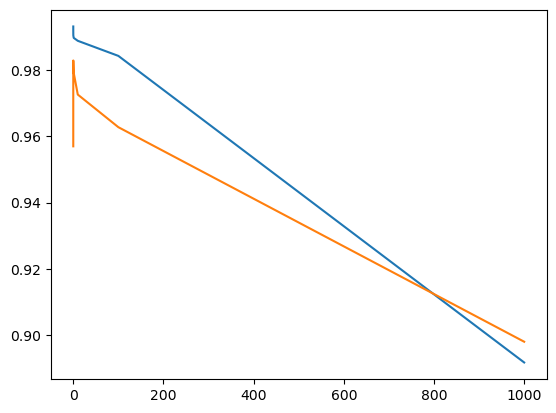

In [28]:
# 시각화 하기
import matplotlib.pyplot as plt

plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)

plt.show()

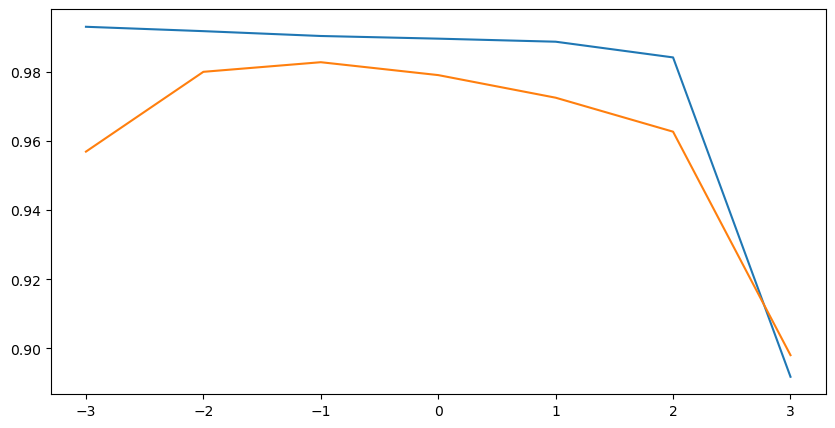

In [29]:
# 시각화하기
import numpy as np

plt.figure(figsize=(10,5))
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)

plt.show()

> alpha가 -1인 경우가 train과 test의 간격이 제일 가깝다 (골디락스(Goldilocks)).   
-1 -> 0.1

In [30]:
ridge = Ridge(alpha=0.1) # default : alpha = 0.1
ridge.fit(train_scaled, train_target)
print("train score :", ridge.score(train_scaled, train_target))
print("test score :", ridge.score(test_scaled, test_target))

train score : 0.9903815817570366
test score : 0.9827976465386955


---
### Lasso(L1 규제) 회귀
: Lasso 규제는 가중치의 절대값으로 규제하는 방법

In [31]:
from sklearn.linear_model import Lasso

lasso = Lasso() # default : alpha = 1
lasso.fit(train_scaled, train_target)
print("train score :", lasso.score(train_scaled, train_target))
print("test score :", lasso.score(test_scaled, test_target))

train score : 0.989789897208096
test score : 0.9800593698421884


In [32]:
# 적절한 규제 강도 찾기
train_score = []
test_score = []


alpha_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alpha_list:
  lasso = Lasso(alpha=alpha)
  lasso.fit(train_scaled, train_target)
  train_score.append(lasso.score(train_scaled, train_target))
  test_score.append(lasso.score(test_scaled, test_target))

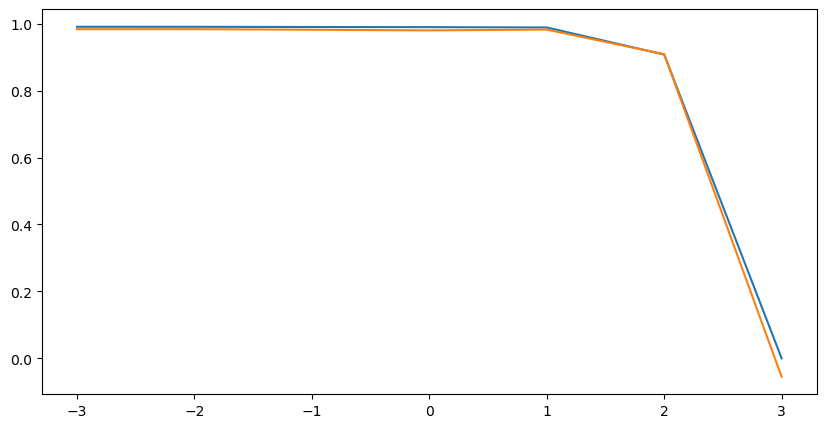

In [33]:
# 시각화하기
import numpy as np

plt.figure(figsize=(10,5))
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)

plt.show()

In [34]:

lasso = Lasso(alpha=1) # default : alpha = 1
lasso.fit(train_scaled, train_target)
print("train score :", lasso.score(train_scaled, train_target))
print("test score :", lasso.score(test_scaled, test_target))

train score : 0.989789897208096
test score : 0.9800593698421884


In [35]:
train_scaled.shape

(42, 55)

In [36]:
np.sum(lasso.coef_ == 0)

42

In [37]:
np.sum(ridge.coef_ == 0)

0

In [38]:
lasso.coef_
# 필요없으면 다 0으로 만들어버려서 특성을 뭉개버린다.

array([ 0.        ,  0.        ,  0.        , 95.61184844, 11.60230215,
        0.        , 10.5804005 ,  0.        , 31.51508869,  0.        ,
       22.30028081,  0.        , 29.10414951,  0.        ,  0.        ,
       18.50441438,  0.        ,  0.        , 41.93702532,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        5.74835225,  0.        ,  0.        ,  0.        , 20.53363452,
        0.        ,  0.        ,  0.        ,  8.8783085 ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , 35.3124872 ,
        0.        ,  0.        ,  0.        ,  0.        , 21.35881131,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [39]:
ridge.coef_
# 제곱을 하기 때문에 0값은 없다.

array([[ 27.61933479,  -1.64022156, -19.73256036,  30.0306195 ,
         16.99800255,  17.83247301,   4.46928273,   3.87258547,
         22.8351822 ,  19.50417483,  17.75985317,  14.53122144,
         13.34875736,   7.57294011,  19.2573194 ,   5.12766348,
         -2.05671393,  10.62376405,  41.72322888,   5.90722851,
         14.93389276,  -0.4506018 ,  19.86035413,   1.27084276,
         -1.00708878,  19.69043816,  -1.15817017,  -3.57357468,
         11.96629206,  13.68484378,  -8.41738209,  -9.97919956,
          8.42421045,  45.51544903,  -6.23828569,  13.36080282,
        -17.64759601,  28.23566212,  -6.56619234, -25.89115813,
         37.3785331 ,  -0.39779345, -20.82275921, -23.80607786,
         39.96650626,   0.10569722, -20.49768851, -21.74712923,
         -4.12579289,  35.39224119,  -5.59195   , -25.3889504 ,
        -23.93962265,  -1.89229971,  39.44235556]])